# Вычисления на GPU

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Макрушин С.В. Лекция "GPGPU"
* https://numpy.org/doc/stable/reference/generated/numpy.load.html
* https://docs.cupy.dev/en/stable/user_guide/basic.html
* https://carpentries-incubator.github.io/gpu-speedups/01_CuPy_and_Numba_on_the_GPU/index.html
* https://carpentries-incubator.github.io/lesson-gpu-programming/02-cupy/index.html
* https://carpentries-incubator.github.io/gpu-speedups/01_CuPy_and_Numba_on_the_GPU/index.html
* https://www.youtube.com/watch?v=9bBsvpg-Xlk
* https://numba.pydata.org/numba-doc/latest/user/vectorize.html
* https://numba.pydata.org/numba-doc/latest/cuda/ufunc.html
* https://towardsdatascience.com/cuda-by-numba-examples-1-4-e0d06651612f


Для выполнения данной работы рекомендуется использовать среду Google Colab. Перед началом работы смените среду выполнения на GPU. 

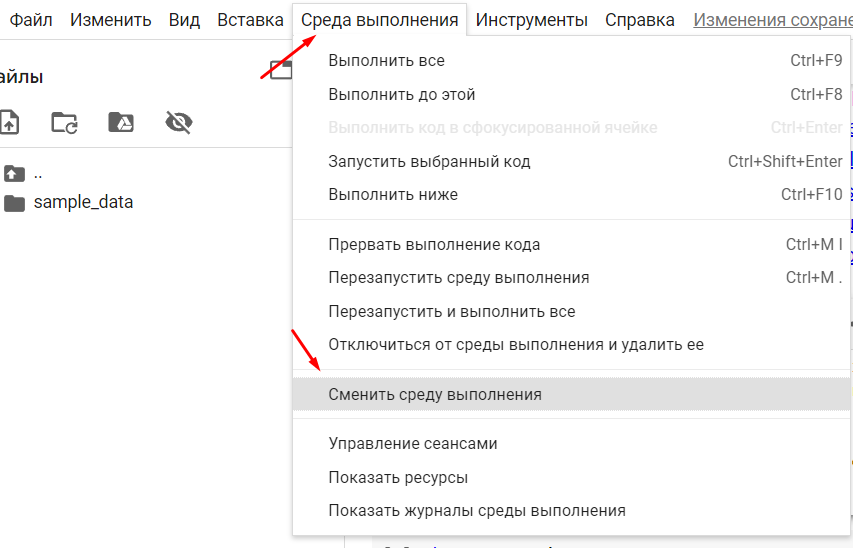

Обратите внимание, что время графического процессора, которое предоставляет Google, ограничено. 

In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


In [2]:
!nvidia-smi

Sun May 28 20:42:36 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   46C    P8     9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Задачи для совместного разбора

In [3]:
import numpy as np
import cupy as cp

1. Создайте массив `cupy`, заполненный числами из стандартного нормального распределения. Исследуйте основные характеристики массива (размеры, устройство, тип). Сравните время выполнения нескольких аналогичных операций с `numpy` и `cupy`. 

In [2]:
A_cpu = np.random.normal(0, 1, size=(10000, 10000))
A_cpu

array([[-0.06997769, -0.58373694, -0.52688031, ...,  0.32451854,
        -0.47727787,  0.18363825],
       [ 0.25942371, -0.08532211,  1.11816856, ...,  1.17836775,
        -1.97655403, -1.41561123],
       [-0.76917242, -0.37873404, -1.17224213, ...,  1.00645302,
         0.30553323,  0.29032948],
       ...,
       [ 0.84373299, -0.33038052, -1.43744663, ...,  0.52045387,
        -0.28263167, -0.52015537],
       [-0.06733631,  0.22033966,  0.9497925 , ...,  1.04731111,
         1.81839953, -1.35998441],
       [ 0.00729715, -0.62857285, -2.04404448, ..., -0.56119004,
         1.02733781, -1.50340702]])

In [3]:
A_cpu.nbytes

800000000

In [4]:
A_gpu = cp.random.normal(0, 1, size=(10000, 10000))
A_gpu.device

<CUDA Device 0>

In [5]:
%%time
(A_cpu ** 2).sum()

CPU times: user 155 ms, sys: 137 ms, total: 292 ms
Wall time: 291 ms


99983620.12159769

In [6]:
%%time
(A_gpu ** 2).sum()

CPU times: user 397 ms, sys: 27.7 ms, total: 425 ms
Wall time: 653 ms


array(99988724.60093722)

In [7]:
# A_cpu + A_gpu
# cp.linalg.svd(A_cpu)
# np.linalg.svd(A_gpu)

# A = A_cpu
A = A_gpu

In [8]:
xp = cp.get_array_module(A)
xp

<module 'cupy' from '/usr/local/lib/python3.10/dist-packages/cupy/__init__.py'>

In [9]:
xp.sum(A)

array(-4644.99823453)

2. Напишите функцию `f(x, y)`, которая считает sin(x) + cos(y), если они одинакового знака (или хотя бы одно из них равно нулю), и cos(x) + sin(y) в противном случае. Векторизуйте функцию при помощи numba с различными значениями аргумента `target`. Создайте 2 массива и выполните вычисления. Создайте ядро CUDA и выполните те же вычисления.

In [22]:
import math

In [23]:
def f(x, y):
  if x * y >= 0:
    return math.sin(x) + math.cos(y)
  return math.cos(x) + math.sin(y)

In [24]:
A = np.random.randint(-100, 100, size=1_000_000)
B = np.random.randint(-100, 100, size=1_000_000)

In [25]:
A.dtype

dtype('int64')

In [29]:
import numba

f1 = numba.vectorize(["float64(int64, int64)"])(f)
f2 = numba.vectorize(["float64(int64, int64)"], target="parallel")(f)
f3 = numba.vectorize(["float64(int64, int64)"], target="cuda")(f)

In [30]:
%%timeit
f1(A, B)

74.5 ms ± 9.26 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [31]:
%%timeit
f2(A, B)

59.8 ms ± 1.24 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%%timeit
f3(A, B)

![image.png](attachment:image.png)

In [33]:
from numba import cuda

In [35]:
@cuda.jit
def kernel(A, B, C):
  i = cuda.grid(1) # индекс эл-та, который обрабатывается в данном вызове

  if i < len(A):
    x = A[i]
    y = B[i]

    if x * y >= 0:
      r = math.sin(x) + math.cos(y)
    else:
      r = math.cos(x) + math.sin(y)

    C[i] = r

In [36]:
C = np.zeros_like(A, dtype=np.float64)
threadsperblock = 512

In [37]:
N = len(A)
blockspergrid = (N + threadsperblock -1) // threadsperblock 

In [38]:
kernel[blockspergrid, threadsperblock](A, B, C)
C

CudaSupportError: ignored

3. Создайте два тензора `A` и `B`, заполненные числами из стандартного нормального распределения. Решите матричное уравнение `AX = B`. Повторите решение с использованием GPU.

## Лабораторная работа 15

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy`, `cupy`, `numba` и `torch`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

### CyPy

<p class="task" id="1"></p>

1\. В файле "blobs.npz" находится четыре массива: 
* X - 1 млн 128-мерных векторов;
* centers - центроиды кластеров;
* y1 - вариант кластеризации точек;
* y2 - альтернативный вариант кластеризации точек.

Считайте эти данные в виде массива `cupy.ndarray`. Используя пакет `cupy`, вычислите и выведите на экран:
* размерость каждого из заданных массивов;
* объем памяти, занимаемой каждым из массивов (в мегабайтах);
* количество точек в каждом из кластеров в соответствии с разбиением `y1`;
* количество точек в каждом из кластеров в соответствии с разбиением `y2`.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

array = np.load('/content/drive/My Drive/blobs.npz')

Mounted at /content/drive


In [5]:
array.files

['X', 'y1', 'y2', 'centers']

In [6]:
array_cupy = cp.load('/content/drive/My Drive/blobs.npz')
array_cupy

In [7]:
# Размерность каждого из заданных массивов:
print('Размерность 1-го массива: ',array_cupy['X'].shape)
print('Размерность 2-го массива: ',array_cupy['y1'].shape)
print('Размерность 3-го массива: ',array_cupy['y2'].shape)
print('Размерность 4-го массива: ',array_cupy['centers'].shape)

Размерность 1-го массива:  (1000000, 128)
Размерность 2-го массива:  (1000000,)
Размерность 3-го массива:  (1000000,)
Размерность 4-го массива:  (3, 128)


In [8]:
# Объем памяти, занимаемой каждым из массивов (в мегабайтах):
print('Размерность 1-го массива: ',array_cupy['X'].nbytes / 1e+6)
print('Размерность 2-го массива: ',array_cupy['y1'].nbytes / 1e+6)
print('Размерность 3-го массива: ',array_cupy['y2'].nbytes / 1e+6)
print('Размерность 4-го массива: ',array_cupy['centers'].nbytes / 1e+6)

Размерность 1-го массива:  1024.0
Размерность 2-го массива:  8.0
Размерность 3-го массива:  8.0
Размерность 4-го массива:  0.003072


In [12]:
# Количество точек в каждом из кластеров в соответствии с разбиением y1:
print('0-ой кластер', np.count_nonzero(array['y1'] == 0))
print('1-ый кластер', np.count_nonzero(array['y1'] == 1))
print('2-ой кластер', np.count_nonzero(array['y1'] == 2))

0-ой кластер 333885
1-ый кластер 333352
2-ой кластер 332763


In [13]:
# Количество точек в каждом из кластеров в соответствии с разбиением y2:
print('0-ой кластер', np.count_nonzero(array['y2'] == 0))
print('1-ый кластер', np.count_nonzero(array['y2'] == 1))
print('2-ой кластер', np.count_nonzero(array['y2'] == 2))

0-ой кластер 333334
1-ый кластер 333333
2-ой кластер 333333


<p class="task" id="2"></p>

2\. Используя пакет `numpy`, выясните, какое из разбиений (`y1` или `y2`) лучше разделяет данные на кластеры. Для этого вычислите среднее значение евклидова расстояния от каждой точки до центроида присвоенного ей кластера. Выведите данные значения для обоих разбиений на экран и сделайте вывод. Замерьте время выполнения решения при помощи магической команды `timeit`.

In [14]:
array_cupy['y1']

array([2, 1, 0, ..., 2, 1, 0])

In [15]:
# Используем массив с класстеризацией y1 как маску 
masked_centers_y1 = array_cupy['centers'][array_cupy['y1']]
masked_centers_y1.shape

(1000000, 128)

In [16]:
masked_centers_y2 = array_cupy['centers'][array_cupy['y2']]
masked_centers_y2.shape

(1000000, 128)

In [17]:
array_cupy['X'].shape

(1000000, 128)

In [24]:
%%timeit
distance_y1 = np.sqrt(np.sum(np.square(array_cupy['X']-masked_centers_y1),axis=1))
mean_distance_y1 = np.mean(distance_y1)

1.69 s ± 204 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [25]:
%%timeit
distance_y2 = np.sqrt(np.sum(np.square(array_cupy['X']-masked_centers_y2),axis=1))
mean_distance_y2 = np.mean(distance_y2)

1.6 s ± 69.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
print('Среднее значение евклидова расстояния для y1: ',mean_distance_y1)
print('Среднее значение евклидова расстояния для y2: ',mean_distance_y2)

Среднее значение евклидова расстояния для y1:  69.6272457739018
Среднее значение евклидова расстояния для y2:  11.292487638331732


__Вывод:__\
Так как среднее значение евклидова расстояния от каждой точки до центроида присвоенного ей кластера меньше для вектора с кластеризацией  по варианту y2, то лучше разделяет на кластеры разбиение y2.

<p class="task" id="3"></p>

3\. Решите задачу 2, воспользовавшись пакетом `cupy`. Замерьте время выполнения решения при помощи магической команды `timeit`. Сравните время выполнения двух решений. Подтвердите (программно), что результаты решений совпадают.

In [33]:
%%timeit
distance_y1_cupy = cp.sqrt(cp.sum(cp.square(array_cupy['X']-masked_centers_y1),axis=1))
mean_distance_y1_cupy = cp.mean(distance_y1_cupy)

1.57 s ± 51.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [34]:
%%timeit
distance_y2_cupy = cp.sqrt(cp.sum(cp.square(array_cupy['X']-masked_centers_y2),axis=1))
mean_distance_y2_cupy = cp.mean(distance_y2_cupy)

1.66 s ± 162 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
print('Среднее значение евклидова расстояния для y1: ', mean_distance_y1_cupy)
print('Среднее значение евклидова расстояния для y2: ',mean_distance_y2_cupy)

Среднее значение евклидова расстояния для y1:  69.6272457739018
Среднее значение евклидова расстояния для y2:  11.292487638331732


In [31]:
# Результаты для y1:
mean_distance_y1_cupy == mean_distance_y1

array(True)

In [32]:
# Результаты для y2:
mean_distance_y2_cupy == mean_distance_y2

array(True)

<p class="task" id="4"></p>

4\. Напишите функцию `test_y`, которая считает среднее значение евклидова расстояния от каждой точки до центроида присвоенного ей кластера. Реализуйте функцию таким образом, чтобы она могла корректно работать и с массивами `numpy`, и с массивами `cupy`. Если в функции передается часть аргументов в виде массивов `numpy`, а часть - в виде массивов `cupy`, должно быть возбуждено исключение `ValueError`. Подтвердите правильность решения различными примерами.

```python
def test_y(X, y, centers):
  pass
```

In [35]:
type(array['X']),type(array_cupy['X'])

(numpy.ndarray, cupy.ndarray)

In [36]:
def test_y(X,y,centers):
    if [type(X),type(y),type(centers)] == [np.ndarray, np.ndarray, np.ndarray]:
      return np.mean(np.sqrt(np.sum(np.square(X - centers[y]),axis=1)))

    elif [type(X),type(y),type(centers)] == [cp.ndarray, cp.ndarray, cp.ndarray]:
      return cp.mean(cp.sqrt(cp.sum(cp.square(X - centers[y]),axis=1)))
    else:
      raise ValueError('Часть аргументов являются numpy.ndarray, а часть cupy.ndarray')

In [37]:
test_y(array_cupy['X'],array_cupy['y1'],array_cupy['centers'])

array(69.62724577)

In [38]:
test_y(array['X'],array['y1'],array['centers'])

69.6272457739018

In [39]:
test_y(array_cupy['X'],array['y1'],array['centers'])

ValueError: ignored

### Numba

<p class="task" id="5"></p>

5\. Даны массива `numbers` и `powers`. Реализуйте функцию `power_sum`, которая находит сумму всех цифр числа `number`, возведенных в степень `power`. Для каждой пары `(numbers[i], power[i])` вычислите `power_sum` , найдите максимум этой величины и выведите ее на экран. Решите задачу при помощи декоратора `numba.vectorize` с различными значениями аргумента `target`: `cpu`, `parallel` и `cuda`. Замерьте время выполнения каждого из решений.

```python
def power_sum(number: int, power: int) -> int:
  pass
```

In [40]:
import numpy as np
np.random.seed(42)

N = 10_000_000

numbers = np.random.randint(0, 1000, size=N)
powers = np.random.randint(1, 5, size=N)

In [41]:
def power_sum(number: int, power: int) -> int:
  if number < 10:
    digits = np.array([number])
  elif 10 <= number < 100:
    digits = np.array([number//10,number%10])
  else:
    digits = np.array([number//100, number//10%10, number%10])
  return np.sum(np.power(digits,power))

In [42]:
%%time
print('Максимум: ', np.max(np.array([power_sum(numbers[i],powers[i]) for i in range(N)])))

Максимум:  19683
CPU times: user 1min 28s, sys: 525 ms, total: 1min 29s
Wall time: 1min 29s


In [43]:
numbers.dtype,powers.dtype

(dtype('int64'), dtype('int64'))

In [44]:
import numba

In [45]:
power_sum_cpu = numba.vectorize(["int64(int64, int64)"],target="cpu")(power_sum)
power_sum_parallel = numba.vectorize(["int64(int64, int64)"],target="parallel")(power_sum)

In [55]:
%%time
max(power_sum_cpu(numbers,powers))

CPU times: user 3.59 s, sys: 13.5 ms, total: 3.61 s
Wall time: 3.7 s


19683

In [54]:
%%time
max(power_sum_parallel(numbers,powers))

CPU times: user 4.75 s, sys: 16.5 ms, total: 4.77 s
Wall time: 3.23 s


19683

In [48]:
def power_sum(number: int, power: int) -> int:
  if number < 10:
    return number ** power

  elif 10 <= number < 100:
    digit_1 = number // 10
    digit_2 = number % 10
    return digit_1 ** power + digit_2 ** power
    
  else:
    digit_1 = number // 100
    digit_2 =  number // 10 % 10
    digit_3 = number % 10
    return digit_1 ** power + digit_2 ** power + digit_3 ** power

In [49]:
power_sum_cuda = numba.vectorize(["int64(int64, int64)"],target="cuda")(power_sum)

In [52]:
%%time
max(power_sum_cuda(numbers,powers))

CPU times: user 979 ms, sys: 17.7 ms, total: 996 ms
Wall time: 1.02 s


19683

<p class="task" id="6"></p>

6\. Преобразуйте `power_sum` в device function при помощи декоратора `numba.cuda.jit`. Напишите ядро `power_sum_kernel` и решите с его помощью задачу 5.

In [129]:
from numba import cuda

In [137]:
@cuda.jit("int64(int64, int64)", device=True)
def power_sum(number: int, power: int) -> int:
  if number < 10:
    return number ** power

  elif 10 <= number < 100:
    digit_1 = number // 10
    digit_2 = number % 10
    return digit_1 ** power + digit_2 ** power
    
  else:
    digit_1 = number // 100
    digit_2 =  number // 10 % 10
    digit_3 = number % 10
    return digit_1 ** power + digit_2 ** power + digit_3 ** power

### PyTorch

<p class="task" id="7"></p>

7\. Создайте тензор размера 256х64. Заполните его числами из равномерного распределения $U(-a, a)$, где $a=3\sqrt{\frac{6}{256+64}}$. Выведите на экран основные характеристики тензора:
* кол-во строк;
* кол-во столбцов;
* кол-во элементов;
* тип данных;
* устройство.

In [56]:
import torch as th

In [57]:
a = 3 * np.sqrt(6 / (256 + 64))
tensor = th.empty((256,64)).uniform_(-a, a)   

In [58]:
print('Количество строк: ', tensor.shape[0])
print('Количество столбцов: ', tensor.shape[1])
print('Количество элементов: ', tensor.numel())
print('Тип данных: ', type(tensor))
print('Устройство: ', tensor.device)

Количество строк:  256
Количество столбцов:  64
Количество элементов:  16384
Тип данных:  <class 'torch.Tensor'>
Устройство:  cpu


<p class="task" id="8"></p>

8\. Создайте тензор `A`, заполненный целыми числами из отрезка [-1, 1] (при создании зафиксируйте зерно ГПСЧ, равное 42). Получите матрицу B по правилу $B = \frac{A + A^T}{2}$. Проверьте, является ли матрица симметричной. Используя `torch`, получите SVD-разложение матрицы `B`. Проверьте, насколько точно разложение приближает исходную матрицу (для оценки качества используйте норму Фробениуса). Измерьте время выполнения решения.

In [59]:
th.manual_seed(42)

In [60]:
A = th.randint(-1,2,(100,100),dtype=th.float)
A

tensor([[-1.,  1.,  0.,  ...,  0.,  1.,  1.],
        [ 0., -1., -1.,  ...,  1.,  0.,  1.],
        [ 0.,  1.,  0.,  ...,  1.,  1.,  0.],
        ...,
        [ 1.,  0.,  0.,  ..., -1.,  0., -1.],
        [ 0.,  1.,  0.,  ..., -1.,  1.,  0.],
        [ 1.,  1., -1.,  ..., -1.,  0.,  1.]])

In [61]:
B = (A + A.t()) / 2
B

tensor([[-1.0000,  0.5000,  0.0000,  ...,  0.5000,  0.5000,  1.0000],
        [ 0.5000, -1.0000,  0.0000,  ...,  0.5000,  0.5000,  1.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.5000,  0.5000, -0.5000],
        ...,
        [ 0.5000,  0.5000,  0.5000,  ..., -1.0000, -0.5000, -1.0000],
        [ 0.5000,  0.5000,  0.5000,  ..., -0.5000,  1.0000,  0.0000],
        [ 1.0000,  1.0000, -0.5000,  ..., -1.0000,  0.0000,  1.0000]])

In [62]:
# Матрица симметрична

In [63]:
from torch import linalg as LA

In [64]:
%%time
U, S, V = th.svd(B)
svd_matrix = th.mm(th.mm(U, th.diag(S)), V.t())
LA.norm((A - svd_matrix),'fro')

CPU times: user 5.35 ms, sys: 2.19 ms, total: 7.55 ms
Wall time: 120 ms


tensor(57.7841)

In [65]:
th.dist(A, th.matmul(th.matmul(U, th.diag_embed(S)), V.mT))

tensor(57.7841)

<p class="task" id="9"></p>

9\. Повторите решение задачи 8, перенеся вычисления на GPU. Сравните результаты и время выполнения двух решений.

In [66]:
device = th.device("cuda")
A_gpu = A.to(device)

In [67]:
A_gpu.device

device(type='cuda', index=0)

In [68]:
B_gpu = (A_gpu + A_gpu.t()) / 2

In [70]:
%%time
U_gpu, S_gpu, V_gpu = th.svd(B_gpu)
svd_matrix_gpu = th.mm(th.mm(U_gpu, th.diag(S_gpu)), V_gpu.t())
LA.norm((A_gpu - svd_matrix_gpu),'fro')

CPU times: user 8.23 ms, sys: 935 µs, total: 9.16 ms
Wall time: 13.2 ms


tensor(57.7841, device='cuda:0')